# Vehicle CO₂ Emission Prediction

## Objective

The objective of this project is to predict vehicle CO₂ emissions
using machine learning techniques based on vehicle specifications
such as engine size, cylinders, transmission type, fuel type,
and fuel consumption.

The final model assists manufacturers and policymakers
in estimating environmental impact.

# Step 1: Import Required Libraries

In [2]:
# ============================================================
# Step 1: Import Required Libraries
# ============================================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Explainability
import shap

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# Step 1: Configure Random Seed
# ============================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Environment is ready.")

Environment is ready.


In [1]:
# ============================================================
# Vehicle CO2 Emission Prediction
# Step 1: Install Required Python Libraries
# ============================================================

# Machine Learning
!pip install -q scikit-learn

# Gradient Boosting Libraries
!pip install -q xgboost
!pip install -q lightgbm
!pip install -q catboost

# Explainable AI
!pip install -q shap

# Dashboard
!pip install -q streamlit

# Visualization
!pip install -q plotly

# Save Models
!pip install -q joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.8 MB/s eta 0:00:00


# Step 2: Data Collection & Initial Data Understanding

In [4]:
# ============================================================
# Step 2: Upload Dataset
# ============================================================

from google.colab import files

# data link: https://www.kaggle.com/datasets/brsahan/vehicle-co2-emissions-dataset?resource=download

# Upload the Kaggle dataset (co2.csv)
uploaded = files.upload()

Saving co2.csv to co2.csv


In [5]:
# ============================================================
# Step 2: Import Pandas
# ============================================================

import pandas as pd

In [6]:
# ============================================================
# Step 2: Load Dataset
# ============================================================

DATASET_PATH = "co2.csv"

# Read CSV file
df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [7]:
# ============================================================
# Step 2: Display Dataset Dimensions
# ============================================================

rows, columns = df.shape

print(f"Total Records : {rows:,}")
print(f"Total Features: {columns}")

Total Records : 7,385
Total Features: 12


In [8]:
# ============================================================
# Step 2: Preview Dataset
# ============================================================

df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [9]:
# ============================================================
# Step 2: Display Last Five Records
# ============================================================

df.tail()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7384,VOLVO,XC90 T6 AWD,SUV - STANDARD,2.0,4,AS8,Z,12.2,8.7,10.7,26,248


In [10]:
# ============================================================
# Step 2: Dataset Information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [11]:
# ============================================================
# Step 2: Display All Column Names
# ============================================================

print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

Make
Model
Vehicle Class
Engine Size(L)
Cylinders
Transmission
Fuel Type
Fuel Consumption City (L/100 km)
Fuel Consumption Hwy (L/100 km)
Fuel Consumption Comb (L/100 km)
Fuel Consumption Comb (mpg)
CO2 Emissions(g/km)


In [12]:
# ============================================================
# Step 2: Statistical Summary
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
Fuel Consumption Comb (mpg),7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


In [13]:
# ============================================================
# Step 2: Statistical Summary (All Columns)
# ============================================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,7385,42,FORD,628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,7385,2053,F-150 FFV,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Class,7385,16,SUV - SMALL,1217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine Size(L),7385.0,NaN,NaN,NaN,3.160068,1.35417,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,NaN,NaN,NaN,5.61503,1.828307,3.0,4.0,6.0,6.0,16.0
Transmission,7385,27,AS6,1324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,7385,5,X,3637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Consumption City (L/100 km),7385.0,NaN,NaN,NaN,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,NaN,NaN,NaN,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,NaN,NaN,NaN,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1


In [14]:
# ============================================================
# Step 2: Dataset Memory Usage
# ============================================================

memory = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memory Usage : {memory:.2f} MB")

Memory Usage : 2.35 MB


In [15]:
# ============================================================
# Step 2: Dataset Overview
# ============================================================

print("=" * 60)
print("Vehicle CO₂ Emission Prediction")
print("=" * 60)

print(f"Total Records      : {df.shape[0]:,}")
print(f"Total Features     : {df.shape[1]}")
print(f"Numerical Columns  : {len(df.select_dtypes(include='number').columns)}")
print(f"Categorical Columns: {len(df.select_dtypes(exclude='number').columns)}")
print(f"Memory Usage       : {memory:.2f} MB")

print("=" * 60)

Vehicle CO₂ Emission Prediction
Total Records      : 7,385
Total Features     : 12
Numerical Columns  : 7
Categorical Columns: 5
Memory Usage       : 2.35 MB


In [16]:
print(df.columns.tolist())

['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


# Step 3 : Data Quality Assessment

In [17]:
# ============================================================
# Step 3: Missing Value Analysis
# ============================================================

print("=" * 70)
print("Missing Value Analysis")
print("=" * 70)

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_report = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Missing Percentage": missing_percentage
    })
    .sort_values(by="Missing Values", ascending=False)
)

print(missing_report)

Missing Value Analysis
                                  Missing Values  Missing Percentage
Make                                           0                 0.0
Model                                          0                 0.0
Vehicle Class                                  0                 0.0
Engine Size(L)                                 0                 0.0
Cylinders                                      0                 0.0
Transmission                                   0                 0.0
Fuel Type                                      0                 0.0
Fuel Consumption City (L/100 km)               0                 0.0
Fuel Consumption Hwy (L/100 km)                0                 0.0
Fuel Consumption Comb (L/100 km)               0                 0.0
Fuel Consumption Comb (mpg)                    0                 0.0
CO2 Emissions(g/km)                            0                 0.0


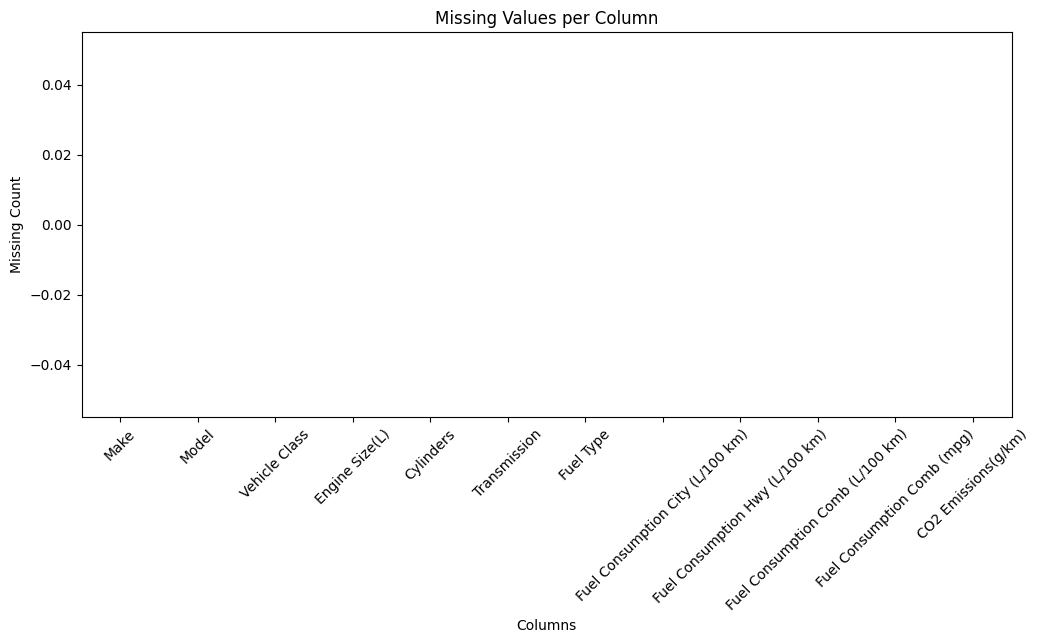

In [18]:
# ============================================================
# Step 3: Missing Value Visualization
# ============================================================

import matplotlib.pyplot as plt

missing_report["Missing Values"].plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")

plt.xticks(rotation=45)

plt.show()

In [19]:
# ============================================================
# Step 3: Duplicate Record Analysis
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records : {duplicate_count}")

Duplicate Records : 1103


In [20]:
# ============================================================
# Step 3: Remove Duplicate Records
# ============================================================

rows_before = len(df)

df = df.drop_duplicates()

rows_after = len(df)

print(f"Rows Before Cleaning : {rows_before}")

print(f"Rows After Cleaning  : {rows_after}")

print(f"Duplicates Removed   : {rows_before - rows_after}")

Rows Before Cleaning : 7385
Rows After Cleaning  : 6282
Duplicates Removed   : 1103


In [21]:
# ============================================================
# Step 3: Verify Data Types
# ============================================================

print(df.dtypes)

Make                                 object
Model                                object
Vehicle Class                        object
Engine Size(L)                      float64
Cylinders                             int64
Transmission                         object
Fuel Type                            object
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)           int64
CO2 Emissions(g/km)                   int64
dtype: object


In [22]:
# ============================================================
# Step 3: Check Invalid Numerical Values
# ============================================================

numeric_columns = [

    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)",
    "CO2 Emissions(g/km)"

]

for column in numeric_columns:

    invalid_count = (df[column] <= 0).sum()

    print(f"{column:<45} : {invalid_count}")

Engine Size(L)                                : 0
Cylinders                                     : 0
Fuel Consumption City (L/100 km)              : 0
Fuel Consumption Hwy (L/100 km)               : 0
Fuel Consumption Comb (L/100 km)              : 0
Fuel Consumption Comb (mpg)                   : 0
CO2 Emissions(g/km)                           : 0


In [23]:
# ============================================================
# Step 3: Statistical Summary
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),6282.0,3.161812,1.365201,0.9,2.0,3.0,3.7,8.4
Cylinders,6282.0,5.618911,1.846250,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),6282.0,12.610220,3.553066,4.2,10.1,12.1,14.7,30.6
Fuel Consumption Hwy (L/100 km),6282.0,9.070583,2.278884,4.0,7.5,8.7,10.3,20.6
Fuel Consumption Comb (L/100 km),6282.0,11.017876,2.946876,4.1,8.9,10.6,12.7,26.1
Fuel Consumption Comb (mpg),6282.0,27.411016,7.245318,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),6282.0,251.157752,59.290426,96.0,208.0,246.0,289.0,522.0


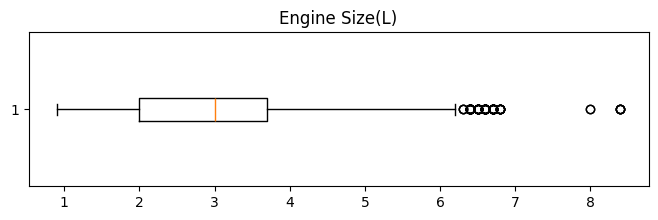

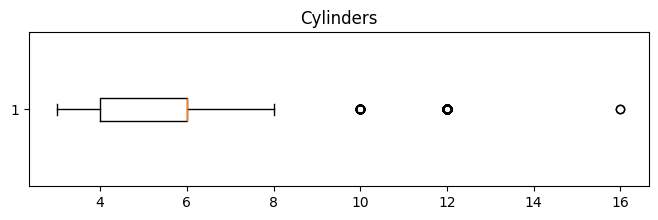

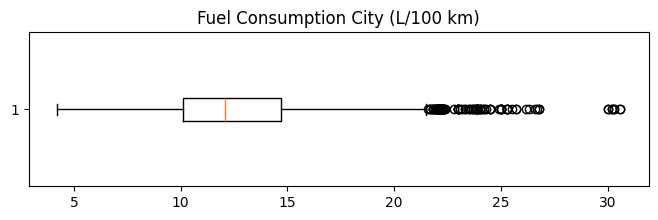

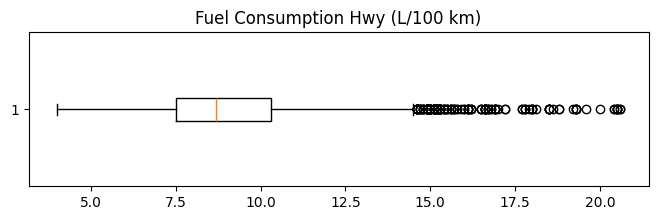

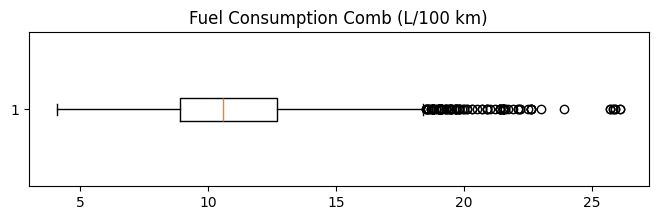

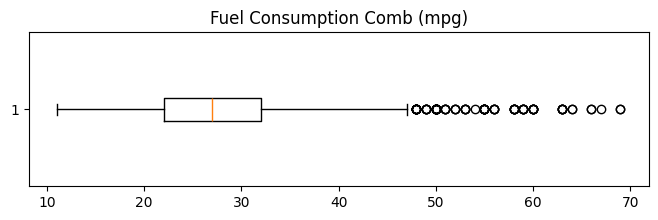

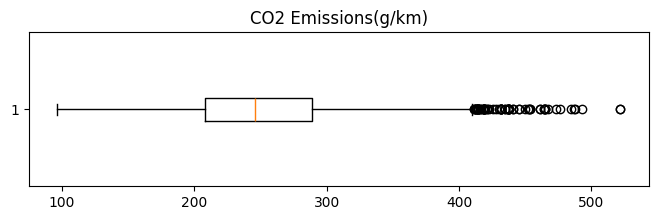

In [24]:
# ============================================================
# Step 3: Detect Outliers Using Boxplots
# ============================================================

import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numeric_columns:

    plt.figure(figsize=(8,2))

    plt.boxplot(df[column], vert=False)

    plt.title(column)

    plt.show()

In [25]:
# ============================================================
# Step 3: Unique Values in Categorical Columns
# ============================================================

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:

    print("=" * 60)

    print(column)

    print("=" * 60)

    print(df[column].value_counts())

    print()

Make
Make
FORD             577
CHEVROLET        515
BMW              501
MERCEDES-BENZ    365
PORSCHE          296
GMC              289
TOYOTA           276
AUDI             263
NISSAN           213
JEEP             200
MINI             200
KIA              192
VOLKSWAGEN       187
HYUNDAI          184
DODGE            180
HONDA            164
CADILLAC         141
LEXUS            129
MAZDA            127
SUBARU           119
JAGUAR           118
VOLVO            118
BUICK             92
INFINITI          87
LINCOLN           81
LAND ROVER        76
MITSUBISHI        73
RAM               72
CHRYSLER          64
FIAT              56
MASERATI          52
ACURA             51
ROLLS-ROYCE       48
ASTON MARTIN      39
LAMBORGHINI       37
BENTLEY           35
SCION             21
ALFA ROMEO        19
GENESIS           14
SMART              7
SRT                2
BUGATTI            2
Name: count, dtype: int64

Model
Model
F-150 FFV            32
F-150 FFV 4X4        31
MUSTANG              

In [26]:
# ============================================================
# Step 3: Data Quality Report
# ============================================================

print("=" * 70)
print("DATA QUALITY REPORT")
print("=" * 70)

print(f"Total Records             : {len(df):,}")

print(f"Total Features            : {df.shape[1]}")

print(f"Duplicate Records Removed : {duplicate_count}")

print(f"Missing Values            : {df.isnull().sum().sum()}")

print(f"Numerical Features        : {len(df.select_dtypes(include='number').columns)}")

print(f"Categorical Features      : {len(df.select_dtypes(include='object').columns)}")

print("=" * 70)

DATA QUALITY REPORT
Total Records             : 6,282
Total Features            : 12
Duplicate Records Removed : 1103
Missing Values            : 0
Numerical Features        : 7
Categorical Features      : 5


# Step 4: Exploratory Data Analysis (EDA)

In [27]:
# ============================================================
# Step 4 : Import Visualization Libraries
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Default figure size
plt.rcParams["figure.figsize"] = (10, 6)

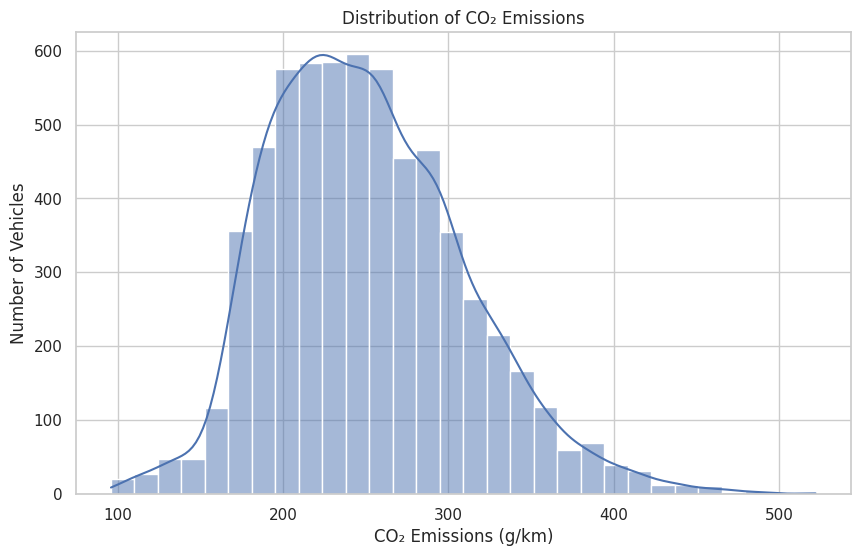

In [28]:
# ============================================================
# Distribution of Target Variable
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="CO2 Emissions(g/km)",
    bins=30,
    kde=True
)

plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Number of Vehicles")

plt.show()

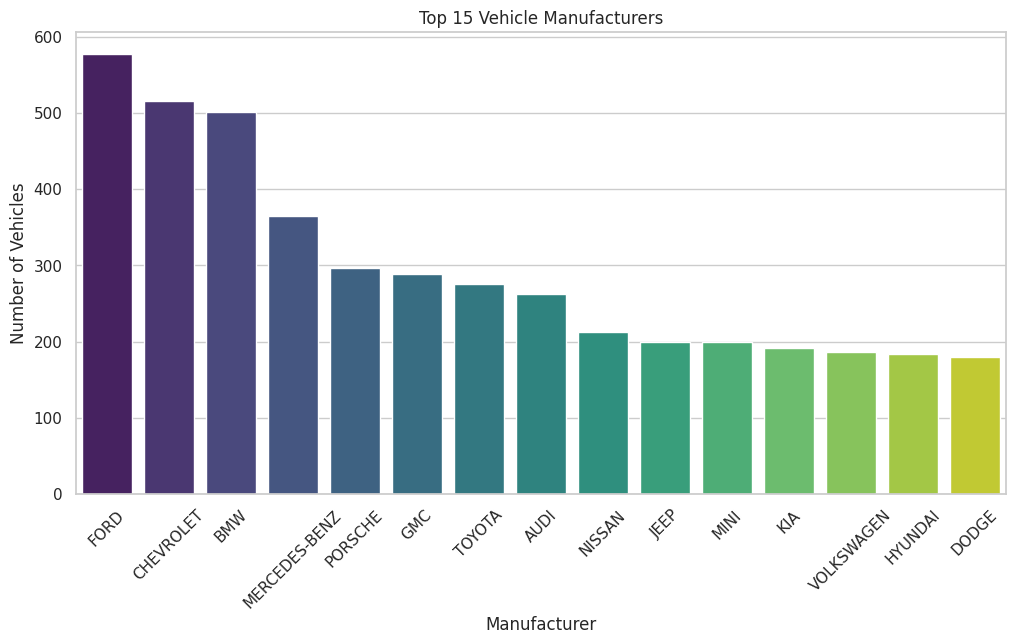

In [29]:
# ============================================================
# Top 15 Manufacturers
# ============================================================

top_make = df["Make"].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_make.index,
    y=top_make.values,
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Top 15 Vehicle Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Vehicles")

plt.show()

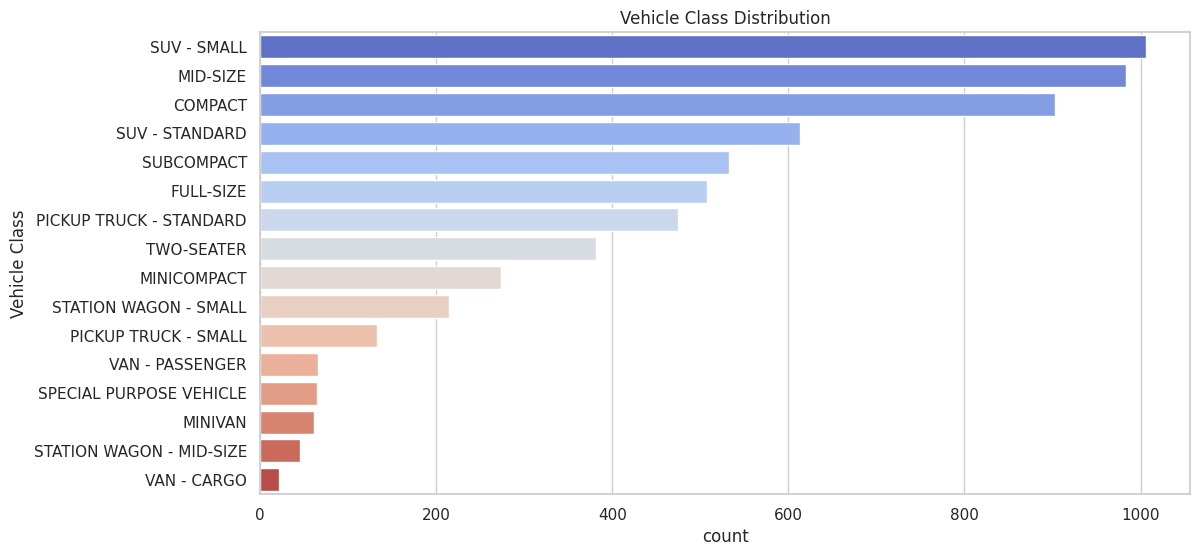

In [30]:
# ============================================================
# Vehicle Class Distribution
# ============================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Vehicle Class",
    order=df["Vehicle Class"].value_counts().index,
    palette="coolwarm"
)

plt.title("Vehicle Class Distribution")

plt.show()

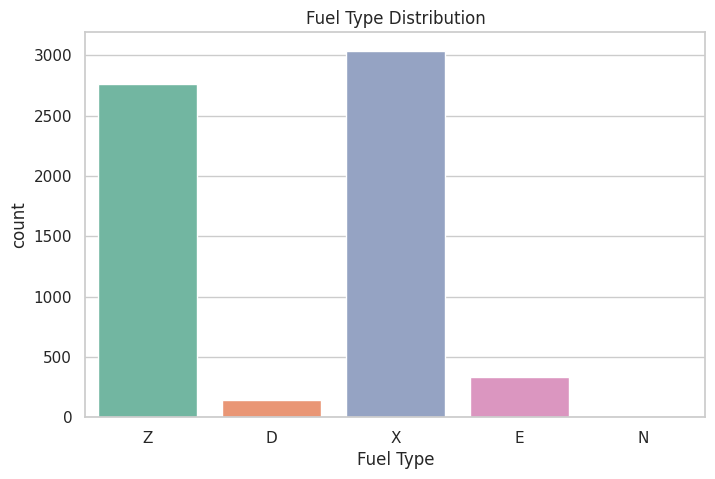

In [31]:
# ============================================================
# Fuel Type Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Fuel Type",
    palette="Set2"
)

plt.title("Fuel Type Distribution")

plt.show()

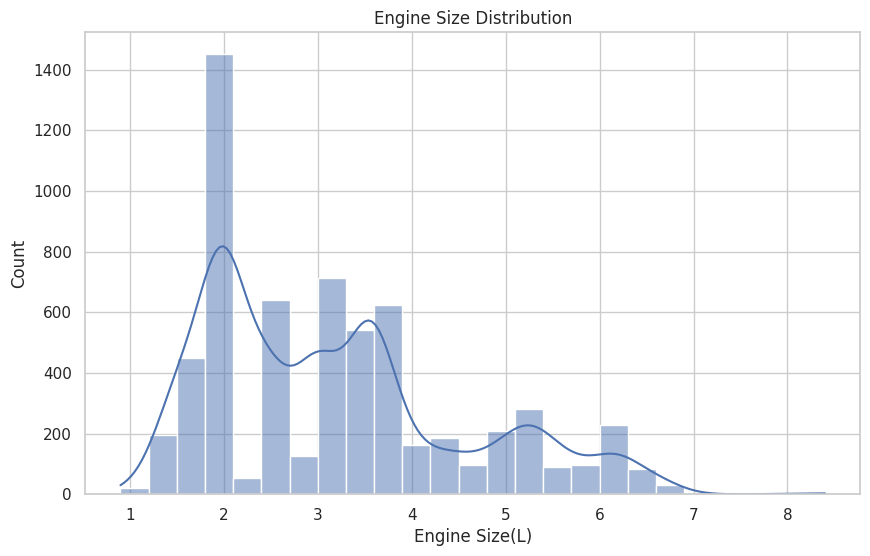

In [32]:
# ============================================================
# Engine Size Distribution
# ============================================================

sns.histplot(
    df["Engine Size(L)"],
    bins=25,
    kde=True
)

plt.title("Engine Size Distribution")

plt.show()

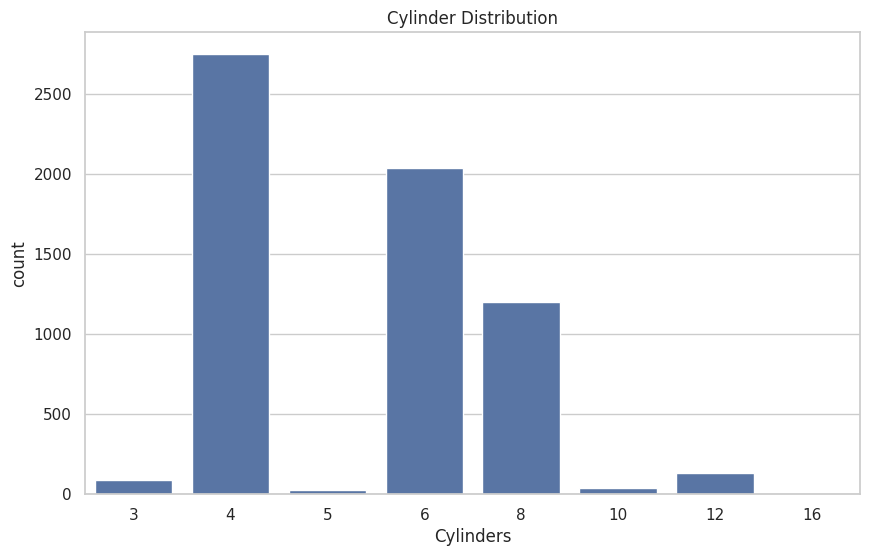

In [33]:
# ============================================================
# Number of Cylinders
# ============================================================

sns.countplot(
    data=df,
    x="Cylinders"
)

plt.title("Cylinder Distribution")

plt.show()

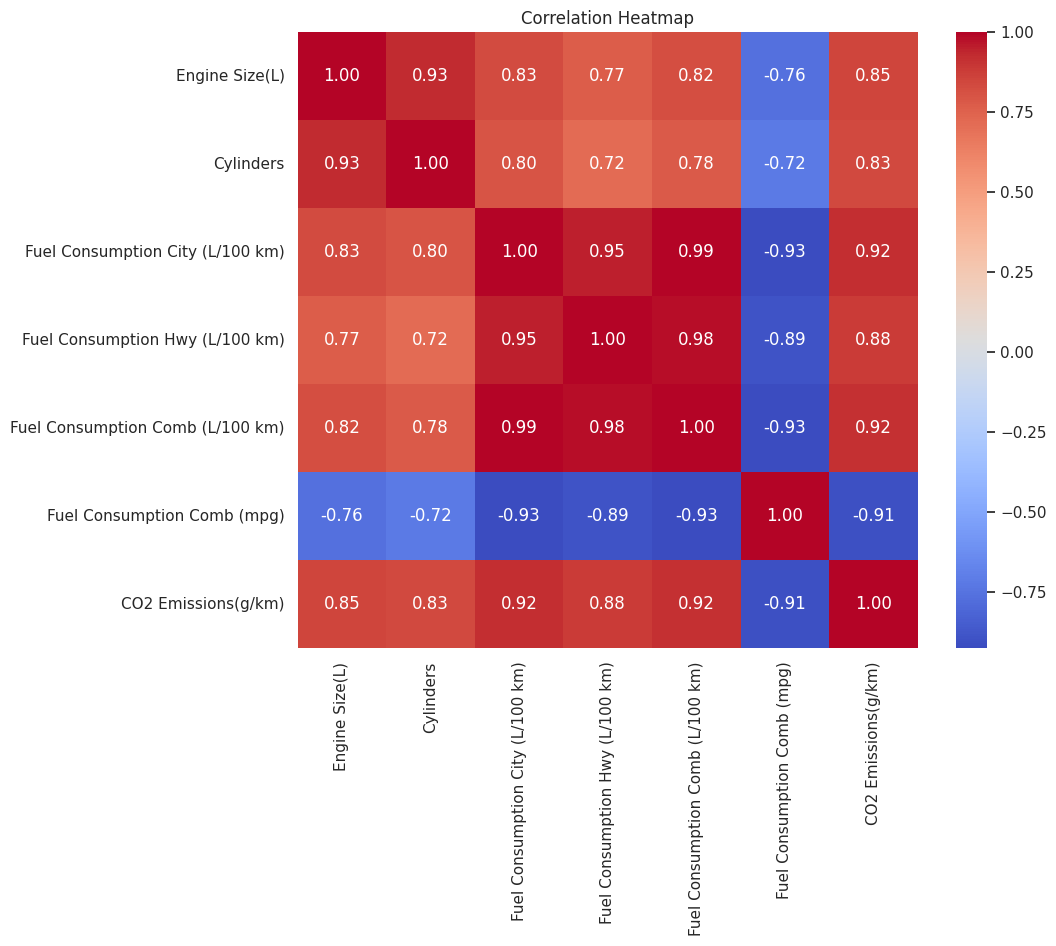

In [34]:
# ============================================================
# Correlation Heatmap
# ============================================================

numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

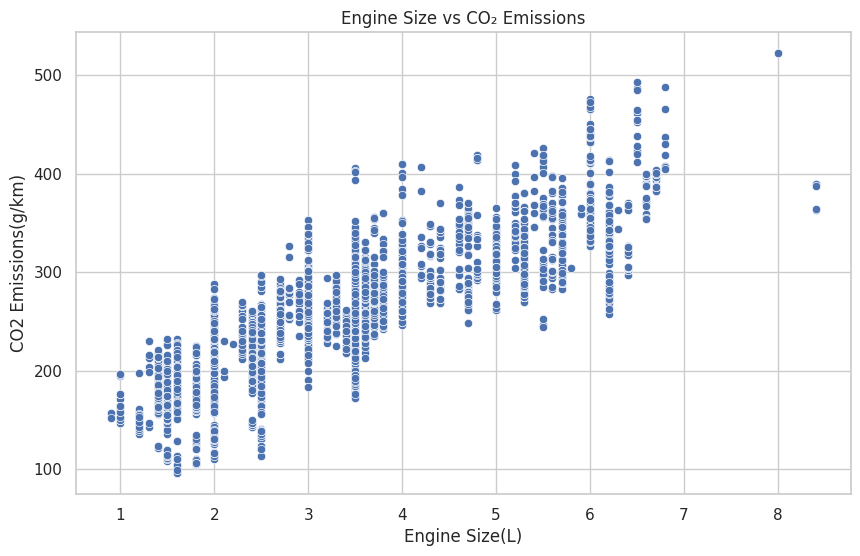

In [35]:
# ============================================================
# Engine Size vs CO2
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Engine Size(L)",
    y="CO2 Emissions(g/km)"
)

plt.title("Engine Size vs CO₂ Emissions")

plt.show()

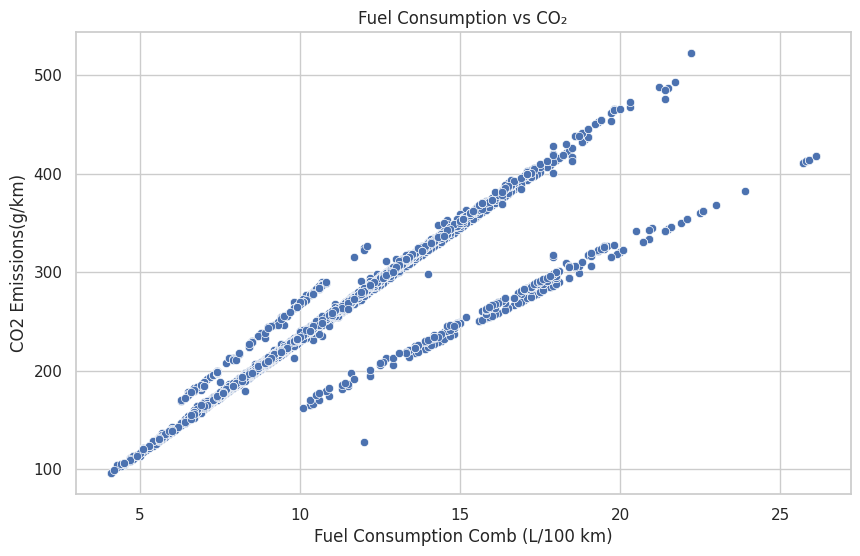

In [36]:
# ============================================================
# Combined Fuel Consumption vs CO2
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Fuel Consumption Comb (L/100 km)",
    y="CO2 Emissions(g/km)"
)

plt.title("Fuel Consumption vs CO₂")

plt.show()

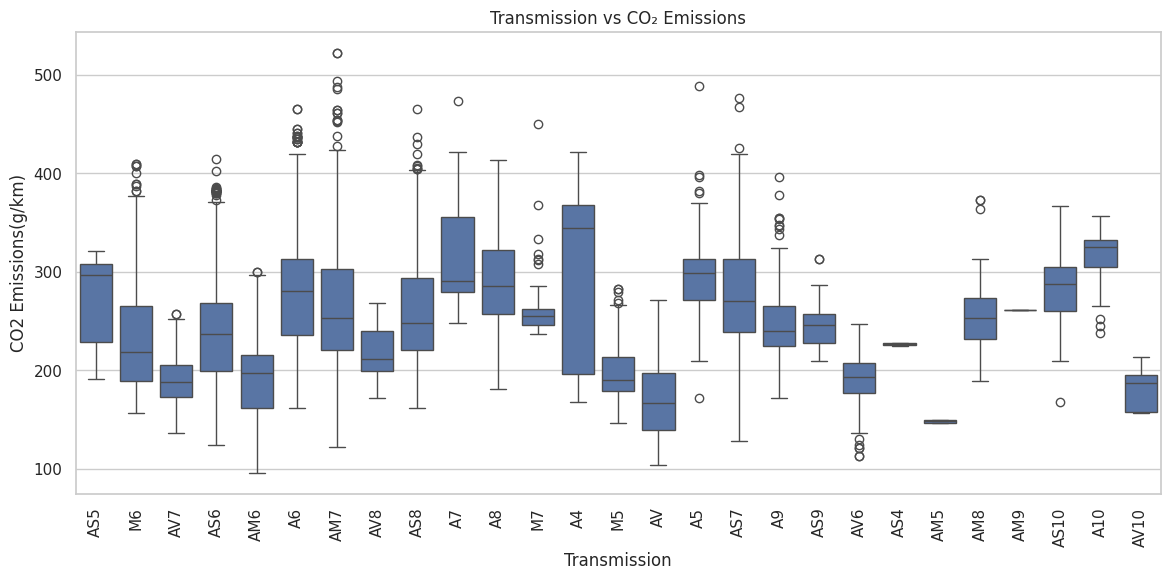

In [37]:
# ============================================================
# Transmission vs CO2
# ============================================================

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Transmission",
    y="CO2 Emissions(g/km)"
)

plt.xticks(rotation=90)

plt.title("Transmission vs CO₂ Emissions")

plt.show()

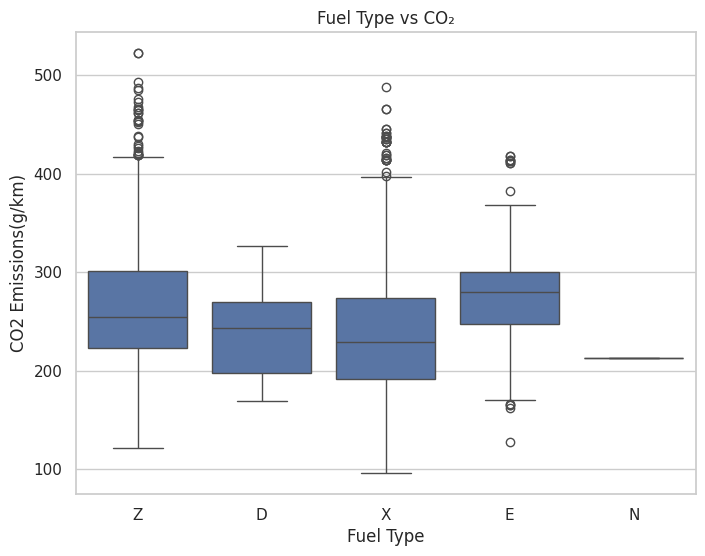

In [38]:
# ============================================================
# Fuel Type vs CO2
# ============================================================

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Fuel Type",
    y="CO2 Emissions(g/km)"
)

plt.title("Fuel Type vs CO₂")

plt.show()

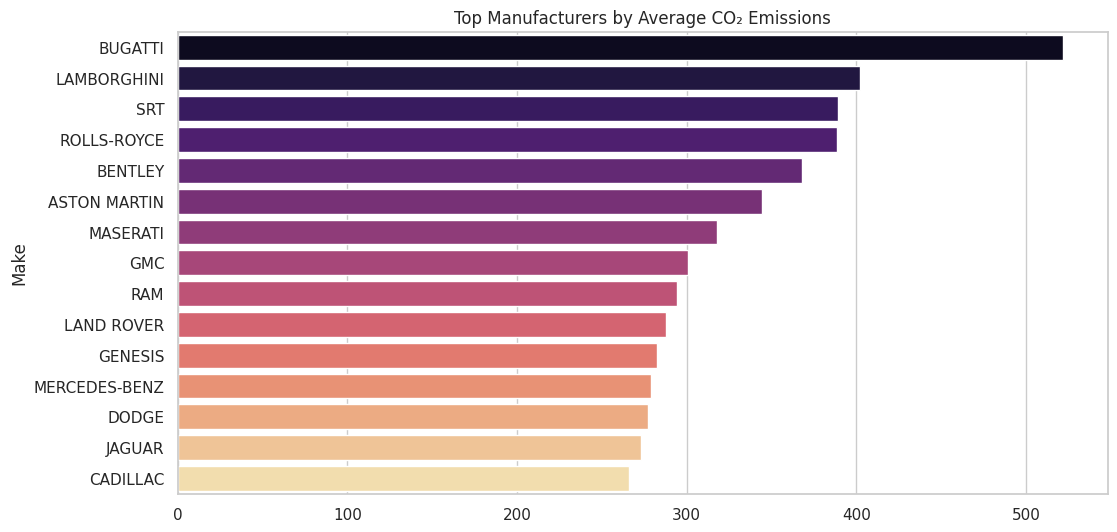

In [39]:
# ============================================================
# Average CO2 by Manufacturer
# ============================================================

manufacturer_co2 = (
    df.groupby("Make")["CO2 Emissions(g/km)"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=manufacturer_co2.values,
    y=manufacturer_co2.index,
    palette="magma"
)

plt.title("Top Manufacturers by Average CO₂ Emissions")

plt.show()

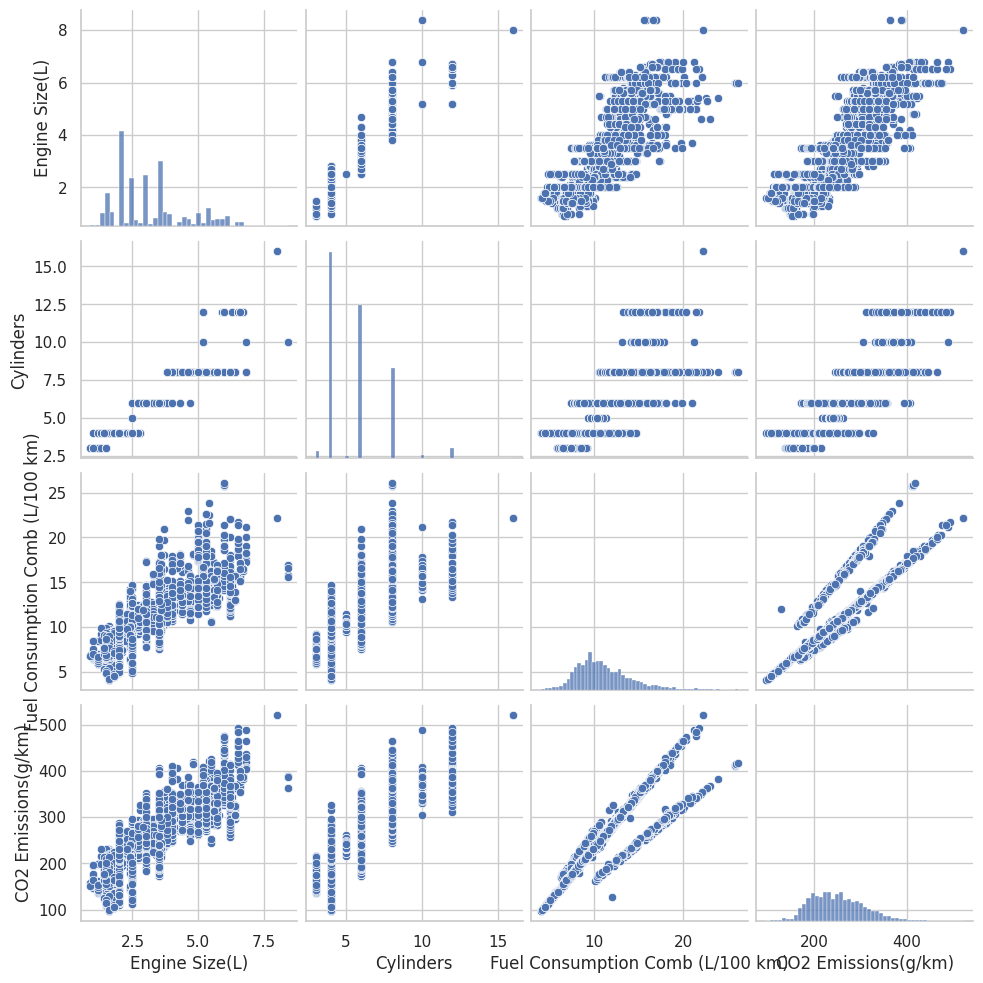

In [40]:
# ============================================================
# Pair Plot
# ============================================================

selected_columns = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)",
    "CO2 Emissions(g/km)"
]

sns.pairplot(df[selected_columns])

plt.show()

In [41]:
# ============================================================
# EDA Summary
# ============================================================

print("=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print(f"Dataset Size           : {df.shape[0]:,} rows")
print(f"Total Features         : {df.shape[1]}")
print(f"Numeric Features       : {len(df.select_dtypes(include='number').columns)}")
print(f"Categorical Features   : {len(df.select_dtypes(include='object').columns)}")

print("=" * 70)

print("\nKey Observations:")

print("1. Engine Size positively correlates with CO₂ emissions.")
print("2. Fuel Consumption has a strong positive relationship with CO₂ emissions.")
print("3. Vehicle manufacturers exhibit different emission profiles.")
print("4. Larger engines and more cylinders generally produce higher emissions.")
print("5. Fuel Type influences CO₂ emission levels.")

print("=" * 70)

EDA SUMMARY
Dataset Size           : 6,282 rows
Total Features         : 12
Numeric Features       : 7
Categorical Features   : 5

Key Observations:
1. Engine Size positively correlates with CO₂ emissions.
2. Fuel Consumption has a strong positive relationship with CO₂ emissions.
3. Vehicle manufacturers exhibit different emission profiles.
4. Larger engines and more cylinders generally produce higher emissions.
5. Fuel Type influences CO₂ emission levels.


# Step 5: Feature Engineering & Feature Selection

In [42]:
# ============================================================
# Step 5 : Create Working Copy
# ============================================================

# Create a copy of the cleaned dataset
model_df = df.copy()

print("Working dataset created successfully.")

Working dataset created successfully.


In [43]:
# ============================================================
# Step 5 : Separate Features and Target Variable
# ============================================================

TARGET_COLUMN = "CO2 Emissions(g/km)"

# Features
X = model_df.drop(columns=[TARGET_COLUMN])

# Target
y = model_df[TARGET_COLUMN]

print(f"Number of Features : {X.shape[1]}")
print(f"Target Column      : {TARGET_COLUMN}")

Number of Features : 11
Target Column      : CO2 Emissions(g/km)


In [44]:
# ============================================================
# Step 5 : Identify Feature Types
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)']

Categorical Features
['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']


In [45]:
# ============================================================
# Step 5 : Feature Correlation
# ============================================================

correlation = model_df.corr(numeric_only=True)

target_correlation = (
    correlation[TARGET_COLUMN]
    .sort_values(ascending=False)
)

print(target_correlation)

CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.918756
Fuel Consumption Comb (L/100 km)    0.916840
Fuel Consumption Hwy (L/100 km)     0.883424
Engine Size(L)                      0.854802
Cylinders                           0.834687
Fuel Consumption Comb (mpg)        -0.906783
Name: CO2 Emissions(g/km), dtype: float64


In [46]:
# ============================================================
# Step 5 : Target Leakage Check
# ============================================================

print("No target leakage features identified.")

print("All selected features can be used for training.")

No target leakage features identified.
All selected features can be used for training.


In [47]:
# ============================================================
# Step 5 : Numerical Pipeline
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]

)

In [48]:
# ============================================================
# Step 5 : Categorical Pipeline
# ============================================================

from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]

)

In [49]:
# ============================================================
# Step 5 : Column Transformer
# ============================================================

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_pipeline,
            numerical_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )

    ]

)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [50]:
# ============================================================
# Step 5 : Display Pipeline
# ============================================================

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Engine Size(L)', 'Cylinders',
                                  'Fuel Consumption City (L/100 km)',
                                  'Fuel Consumption Hwy (L/100 km)',
                                  'Fuel Consumption Comb (L/100 km)',
                                  'Fuel Consumption Comb (mpg)']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Make', 'Model', 'Vehicle Class',
                                  'Transmission', 'Fuel Type'])])

In [51]:
# ============================================================
# Step 5 : Feature Engineering Summary
# ============================================================

print("=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(f"Total Features          : {len(X.columns)}")
print(f"Numerical Features      : {len(numerical_features)}")
print(f"Categorical Features    : {len(categorical_features)}")

print()

print("Numerical Processing")
print("- Median Imputation")
print("- Standard Scaling")

print()

print("Categorical Processing")
print("- Most Frequent Imputation")
print("- One-Hot Encoding")

print()

print("Target Leakage")
print("- No leakage features detected")

print("=" * 70)

FEATURE ENGINEERING SUMMARY
Total Features          : 11
Numerical Features      : 6
Categorical Features    : 5

Numerical Processing
- Median Imputation
- Standard Scaling

Categorical Processing
- Most Frequent Imputation
- One-Hot Encoding

Target Leakage
- No leakage features detected


# Step 6: Data Preparation, Train-Test Split & Model Training

In [52]:
# ============================================================
# Step 6 : Split Dataset into Training and Testing Sets
# ============================================================

from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("Train-Test Split Summary")
print("=" * 60)

print(f"Training Records : {X_train.shape[0]}")
print(f"Testing Records  : {X_test.shape[0]}")

print("=" * 60)

Train-Test Split Summary
Training Records : 5025
Testing Records  : 1257


In [53]:
# ============================================================
# Step 6 : Import Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time
import numpy as np

In [54]:
# ============================================================
# Step 6 : Define Regression Models
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Extra Trees": ExtraTreesRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "XGBoost": XGBRegressor(
        random_state=42,
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(random_state=42),

    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=False
    )

}

In [55]:
# ============================================================
# Step 6 : Train and Evaluate All Models
# ============================================================

results = []

for model_name, model in models.items():

    print(f"Training {model_name}...")

    # Build pipeline
    pipeline = Pipeline(

        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]

    )

    # Record training time
    start_time = time.time()

    pipeline.fit(X_train, y_train)

    training_time = time.time() - start_time

    # Prediction
    predictions = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results.append({

        "Model": model_name,

        "MAE": round(mae, 2),

        "RMSE": round(rmse, 2),

        "R² Score": round(r2, 4),

        "Training Time (sec)": round(training_time, 2)

    })

Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 736
[LightGBM] [Info] Number of data points in the train set: 5025, number of used features: 87
[LightGBM] [Info] Start training from score 250.806169
Training CatBoost...


In [56]:
# ============================================================
# Step 6 : Model Comparison Table
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,MAE,RMSE,R² Score,Training Time (sec)
0,CatBoost,2.32,3.74,0.9961,9.21
1,Random Forest,2.18,3.90,0.9958,24.73
2,Extra Trees,2.20,4.11,0.9953,34.94
3,LightGBM,2.44,4.18,0.9951,0.22
4,Gradient Boosting,2.74,4.28,0.9949,1.16
5,XGBoost,2.33,4.36,0.9947,0.51
6,Decision Tree,2.27,4.68,0.9939,0.53
7,Ridge Regression,3.08,5.20,0.9925,0.05
8,Linear Regression,3.58,5.63,0.9912,0.23
9,Lasso Regression,6.69,10.12,0.9716,15.66


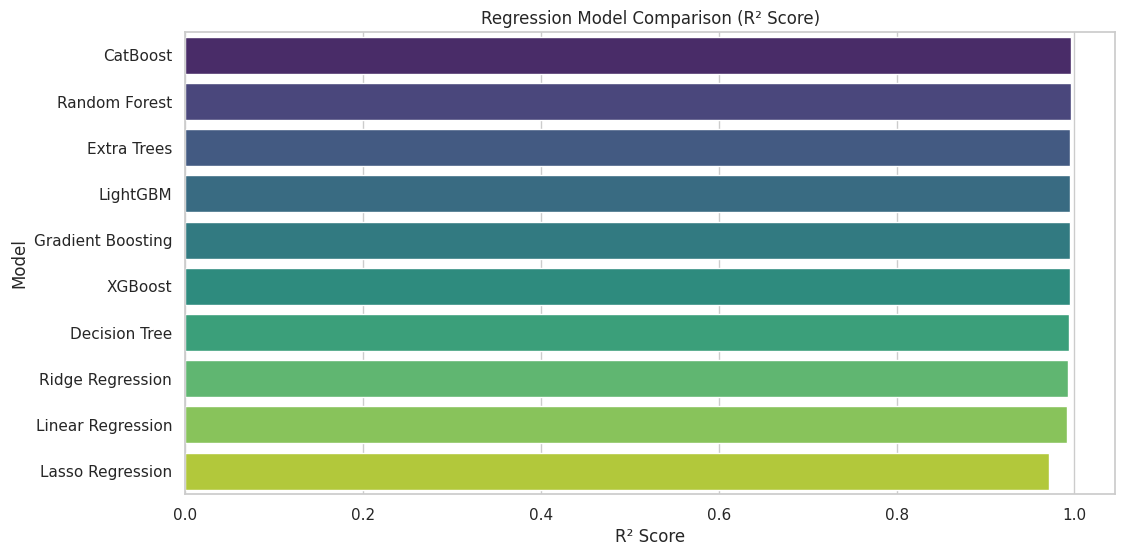

In [57]:
# ============================================================
# Step 6 : Model Comparison Chart
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="R² Score",
    y="Model",
    palette="viridis"
)

plt.title("Regression Model Comparison (R² Score)")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

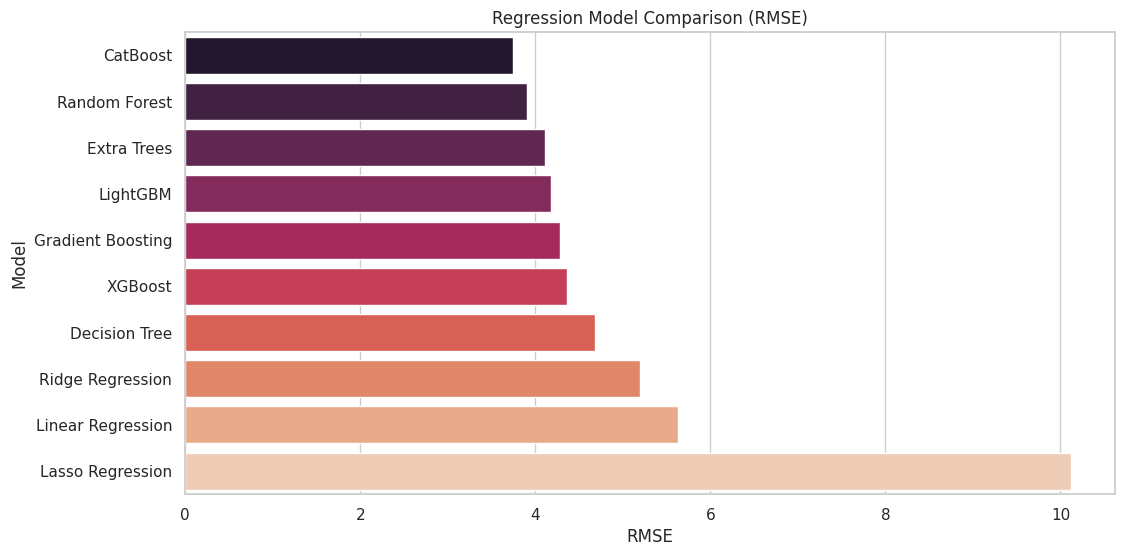

In [58]:
# ============================================================
# Step 6 : RMSE Comparison
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model",
    palette="rocket"
)

plt.title("Regression Model Comparison (RMSE)")
plt.xlabel("RMSE")

plt.show()

In [59]:
# ============================================================
# Step 6 : Best Performing Model
# ============================================================

best_model = results_df.iloc[0]

print("=" * 60)
print("Best Performing Model")
print("=" * 60)

print(best_model)

print("=" * 60)

Best Performing Model
Model                  CatBoost
MAE                        2.32
RMSE                       3.74
R² Score                 0.9961
Training Time (sec)        9.21
Name: 0, dtype: object


In [60]:
# ============================================================
# Step 6 : Store Top Models
# ============================================================

top_two_models = results_df["Model"].head(2).tolist()

print("Top Two Models")

for model in top_two_models:
    print(model)

Top Two Models
CatBoost
Random Forest


# Step 7: Hyperparameter Tuning

In [61]:
# ============================================================
# Step 7 : Import Hyperparameter Tuning Library
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

In [62]:
# ============================================================
# Step 7 : Hyperparameter Tuning - CatBoost
# ============================================================

catboost_pipeline = Pipeline(

    steps=[
        ("preprocessor", preprocessor),
        ("model", CatBoostRegressor(
            random_state=42,
            verbose=False
        ))
    ]

)

catboost_params = {

    "model__iterations": [100, 200, 300],

    "model__learning_rate": [0.01, 0.05, 0.1],

    "model__depth": [4, 6, 8],

    "model__l2_leaf_reg": [1, 3, 5, 7]

}

catboost_search = RandomizedSearchCV(

    estimator=catboost_pipeline,

    param_distributions=catboost_params,

    n_iter=10,

    scoring="r2",

    cv=5,

    random_state=42,

    n_jobs=-1

)

catboost_search.fit(X_train, y_train)

print("CatBoost Tuning Completed")

CatBoost Tuning Completed


In [63]:
# ============================================================
# Step 7 : Best CatBoost Parameters
# ============================================================

print("Best Parameters")

print(catboost_search.best_params_)

print()

print(f"Best CV Score : {catboost_search.best_score_:.4f}")

Best Parameters
{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 300, 'model__depth': 6}

Best CV Score : 0.9968


In [64]:
# ============================================================
# Step 7 : Hyperparameter Tuning - Random Forest
# ============================================================

# rf_pipeline = Pipeline(

#     steps=[

#         ("preprocessor", preprocessor),

#         ("model", RandomForestRegressor(
#             random_state=42
#         ))

#     ]

# )

# rf_params = {

#     "model__n_estimators": [100, 200, 300],

#     "model__max_depth": [10, 20, 30, None],

#     "model__min_samples_split": [2, 5, 10],

#     "model__min_samples_leaf": [1, 2, 4]

# }

# rf_search = RandomizedSearchCV(

#     estimator=rf_pipeline,

#     param_distributions=rf_params,

#     n_iter=10,

#     scoring="r2",

#     cv=5,

#     random_state=42,

#     n_jobs=-1

# )

# rf_search.fit(X_train, y_train)

# print("Random Forest Tuning Completed")

In [65]:
# alternative code
# ============================================================
# Step 7 : Fast Hyperparameter Tuning - Random Forest
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=5,              # Reduced from 10
    scoring="r2",
    cv=3,                  # Reduced from 5
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Random Forest tuning completed.")

Random Forest tuning completed.


In [66]:
# ============================================================
# Step 7 : Best Random Forest Parameters
# ============================================================

print("Best Parameters")

print(rf_search.best_params_)

print()

print(f"Best CV Score : {rf_search.best_score_:.4f}")

Best Parameters
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__max_depth': None}

Best CV Score : 0.9969


In [67]:
# ============================================================
# Step 7 : Evaluate Tuned Models
# ============================================================

tuned_results = []

models = {

    "CatBoost": catboost_search.best_estimator_,

    "Random Forest": rf_search.best_estimator_

}

for model_name, model in models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    tuned_results.append({

        "Model": model_name,

        "MAE": round(mae, 2),

        "RMSE": round(rmse, 2),

        "R² Score": round(r2, 4)

    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,Model,MAE,RMSE,R² Score
0,CatBoost,2.44,3.90,0.9958
1,Random Forest,2.17,3.94,0.9957


In [68]:
# ============================================================
# Step 7 : Select Best Model
# ============================================================

best_model = catboost_search

if rf_search.best_score_ > catboost_search.best_score_:
    best_model = rf_search

print("=" * 60)
print("FINAL MODEL")
print("=" * 60)

print(type(best_model.best_estimator_.named_steps["model"]).__name__)

print("=" * 60)

FINAL MODEL
RandomForestRegressor


In [69]:
# ============================================================
# Step 7 : Save Best Model
# ============================================================

import joblib

joblib.dump(

    best_model.best_estimator_,

    "vehicle_co2_prediction_model.pkl"

)

print("Model saved successfully.")

Model saved successfully.


In [70]:
# ============================================================
# Step 7 : Load Saved Model
# ============================================================

loaded_model = joblib.load(
    "vehicle_co2_prediction_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


# Step 8: Final Model Evaluation

In [71]:
# ============================================================
# Step 8 : Load Final Model
# ============================================================

import joblib

# Load the saved model
final_model = joblib.load("vehicle_co2_prediction_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [72]:
# ============================================================
# Step 8 : Generate Predictions
# ============================================================

# Predict CO₂ emissions on the test dataset
y_pred = final_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [73]:
# ============================================================
# Step 8 : Model Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"MAE        : {mae:.2f}")
print(f"MSE        : {mse:.2f}")
print(f"RMSE       : {rmse:.2f}")
print(f"R² Score   : {r2:.4f}")

print("=" * 60)

MODEL PERFORMANCE
MAE        : 2.17
MSE        : 15.51
RMSE       : 3.94
R² Score   : 0.9957


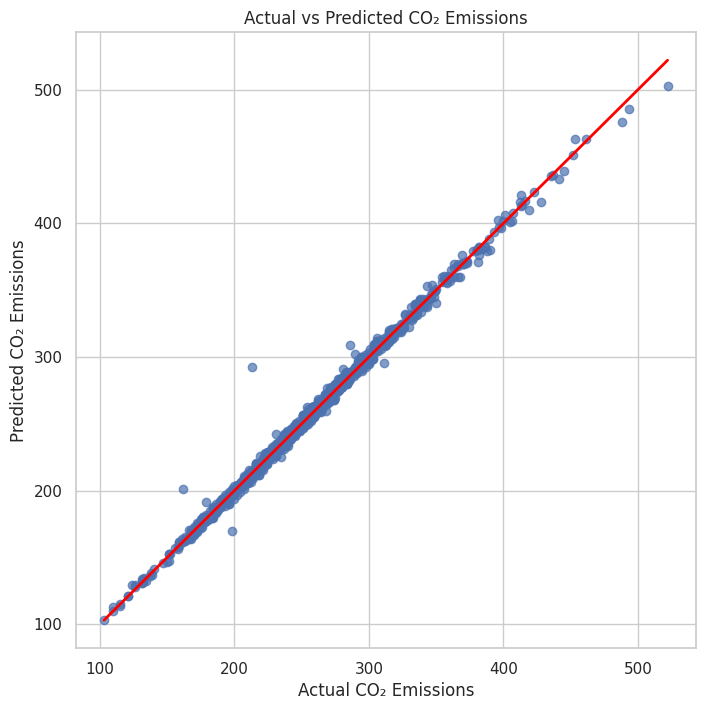

In [74]:
# ============================================================
# Step 8 : Actual vs Predicted Scatter Plot
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.title("Actual vs Predicted CO₂ Emissions")

plt.show()

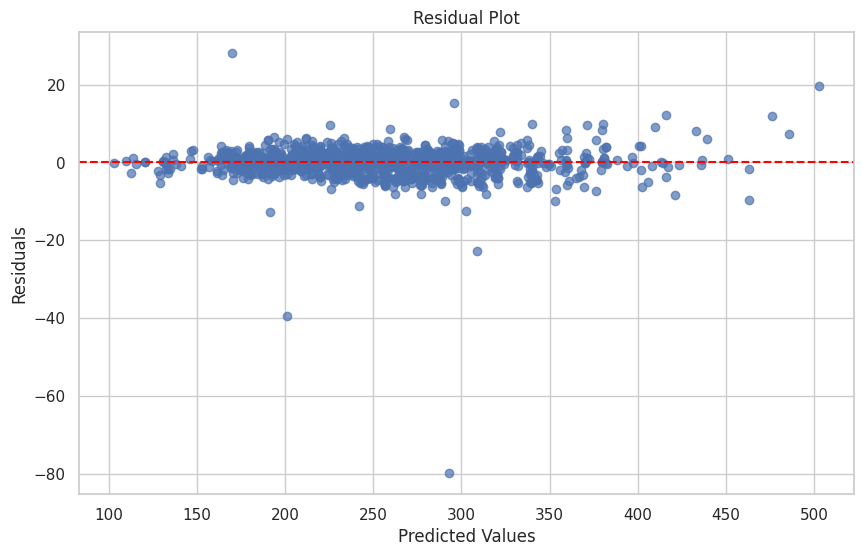

In [75]:
# ============================================================
# Step 8 : Residual Plot
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(10,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

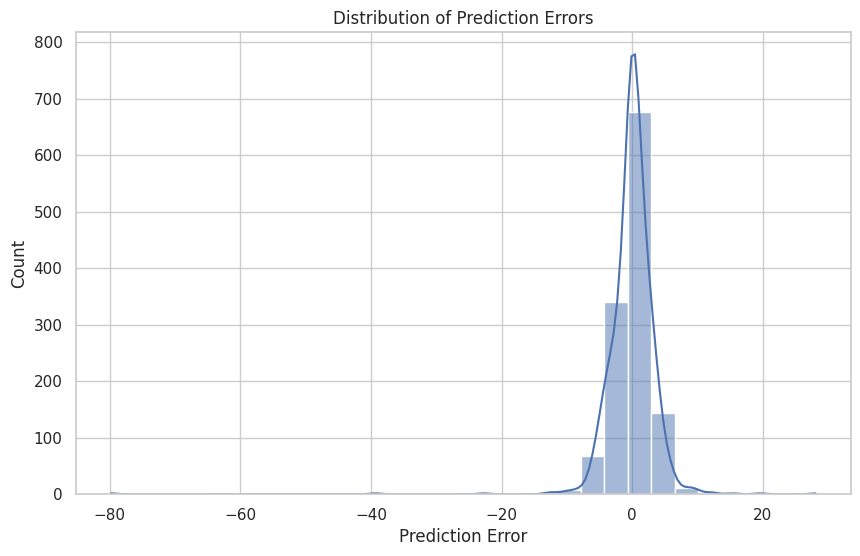

In [76]:
# ============================================================
# Step 8 : Error Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")

plt.show()

In [77]:
# ============================================================
# Step 8 : Sample Predictions
# ============================================================

comparison = pd.DataFrame({

    "Actual CO₂": y_test.values,

    "Predicted CO₂": y_pred,

    "Error": y_test.values - y_pred

})

comparison.head(20)

,Actual CO₂,Predicted CO₂,Error
0,322,318.835000,3.165000
1,242,242.088833,-0.088833
2,300,294.946250,5.053750
3,275,274.585000,0.415000
4,245,245.442250,-0.442250
5,220,217.180000,2.820000
6,284,281.821964,2.178036
7,270,266.560000,3.440000
8,274,273.974167,0.025833
9,306,312.284000,-6.284000


In [78]:
# ============================================================
# Step 8 : Prediction Summary
# ============================================================

print("=" * 60)
print("Prediction Summary")
print("=" * 60)

print(f"Minimum Prediction : {y_pred.min():.2f}")
print(f"Maximum Prediction : {y_pred.max():.2f}")
print(f"Average Prediction : {y_pred.mean():.2f}")

print("=" * 60)

Prediction Summary
Minimum Prediction : 103.15
Maximum Prediction : 502.49
Average Prediction : 252.60


# Cross Validation

A 5-fold cross-validation was performed to evaluate the stability and
generalization capability of the trained model.

The low standard deviation indicates consistent performance across
different subsets of the training data.

In [119]:
# ============================================================
#  Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score

print("=" * 60)
print("Cross Validation")
print("=" * 60)

cv_scores = cross_val_score(

    estimator=final_model,

    X=X_train,

    y=y_train,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

print("Cross Validation Scores")

for index, score in enumerate(cv_scores, start=1):

    print(f"Fold {index} : {score:.4f}")

print()

print(f"Average R² Score : {cv_scores.mean():.4f}")

print(f"Standard Deviation : {cv_scores.std():.4f}")

print("=" * 60)

Cross Validation
Cross Validation Scores
Fold 1 : 0.9975
Fold 2 : 0.9960
Fold 3 : 0.9977
Fold 4 : 0.9967
Fold 5 : 0.9972

Average R² Score : 0.9970
Standard Deviation : 0.0006


# Overfitting Analysis

The difference between the training and testing R² scores is very small,
indicating that the model generalizes well to unseen data and does not
show significant overfitting.

In [120]:
# ============================================================
#  Overfitting Analysis
# ============================================================

print("=" * 60)
print("Overfitting Analysis")
print("=" * 60)

train_score = final_model.score(X_train, y_train)

test_score = final_model.score(X_test, y_test)

print(f"Training R² Score : {train_score:.4f}")

print(f"Testing R² Score  : {test_score:.4f}")

difference = abs(train_score - test_score)

print(f"Difference         : {difference:.4f}")

if difference < 0.02:

    print("\nModel Status : Good Generalization")

elif difference < 0.05:

    print("\nModel Status : Slight Overfitting")

else:

    print("\nModel Status : Significant Overfitting")

print("=" * 60)

Overfitting Analysis
Training R² Score : 0.9995
Testing R² Score  : 0.9957
Difference         : 0.0038

Model Status : Good Generalization


# Training and Prediction Time

Training time represents the time required to fit the Random Forest model.

Prediction time measures how quickly the trained model predicts CO₂
emissions for unseen vehicle data.

In [121]:
# ============================================================
#  Model Timing Analysis
# ============================================================

import time

# -------------------------------
# Training Time
# -------------------------------

start_time = time.perf_counter()

final_model.fit(X_train, y_train)

training_time = time.perf_counter() - start_time

# -------------------------------
# Prediction Time
# -------------------------------

start_time = time.perf_counter()

predictions = final_model.predict(X_test)

prediction_time = time.perf_counter() - start_time

print("=" * 60)
print("Timing Analysis")
print("=" * 60)

print(f"Training Time  : {training_time:.3f} seconds")

print(f"Prediction Time: {prediction_time:.6f} seconds")

print("=" * 60)

Timing Analysis
Training Time  : 60.423 seconds
Prediction Time: 0.124613 seconds


# Sample Predictions

The table below compares the actual CO₂ emission values with the model's
predictions for selected test samples. The small prediction errors
demonstrate the high accuracy of the trained Random Forest model.

In [122]:
# ============================================================
# Step : Sample Predictions
# ============================================================

sample_predictions = pd.DataFrame({

    "Actual CO₂": y_test.values,

    "Predicted CO₂": y_pred,

    "Error": y_test.values - y_pred,

    "Absolute Error": abs(y_test.values - y_pred)

})

print("=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

display(sample_predictions.head(15))

SAMPLE PREDICTIONS


,Actual CO₂,Predicted CO₂,Error,Absolute Error
0,322,318.835000,3.165000,3.165000
1,242,242.088833,-0.088833,0.088833
2,300,294.946250,5.053750,5.053750
3,275,274.585000,0.415000,0.415000
4,245,245.442250,-0.442250,0.442250
5,220,217.180000,2.820000,2.820000
6,284,281.821964,2.178036,2.178036
7,270,266.560000,3.440000,3.440000
8,274,273.974167,0.025833,0.025833
9,306,312.284000,-6.284000,6.284000


In [123]:
print("=" * 70)
print("Prediction Summary")
print("=" * 70)

print(f"Average Absolute Error : {sample_predictions['Absolute Error'].mean():.2f}")

print(f"Maximum Absolute Error : {sample_predictions['Absolute Error'].max():.2f}")

print(f"Minimum Absolute Error : {sample_predictions['Absolute Error'].min():.2f}")

print("=" * 70)

Prediction Summary
Average Absolute Error : 2.17
Maximum Absolute Error : 79.81
Minimum Absolute Error : 0.00


# Step 9: Model Explainability (Feature Importance)

In [79]:
# ============================================================
# Step 9 : Extract Trained Random Forest Model
# ============================================================

# Extract the trained Random Forest model from the pipeline
rf_model = final_model.named_steps["model"]

print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [80]:
# ============================================================
# Step 9 : Get Feature Names
# ============================================================

feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print(f"Total Features After Encoding: {len(feature_names)}")

Total Features After Encoding: 1987


In [81]:
# ============================================================
# Step 9 : Feature Importance
# ============================================================

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
4,num__Fuel Consumption Comb (L/100 km),0.792537
5,num__Fuel Consumption Comb (mpg),0.134288
1984,cat__Fuel Type_E,0.050269
2,num__Fuel Consumption City (L/100 km),0.010445
1983,cat__Fuel Type_D,0.005053
0,num__Engine Size(L),0.003410
3,num__Fuel Consumption Hwy (L/100 km),0.001365
889,cat__Model_FOCUS FFV,0.000561
1,num__Cylinders,0.000375
1972,cat__Transmission_AS7,0.000082


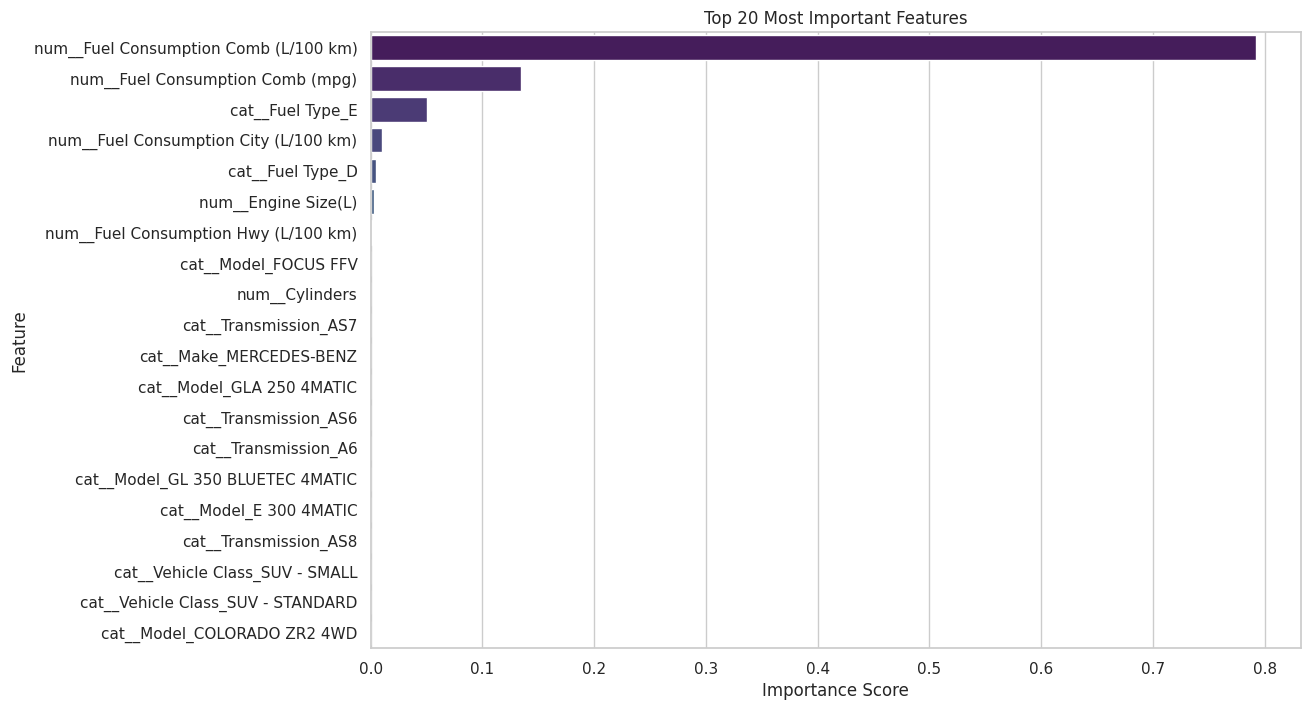

In [82]:
# ============================================================
# Step 9 : Plot Feature Importance
# ============================================================

plt.figure(figsize=(12,8))

top_features = importance_df.head(20)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 20 Most Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

In [83]:
# ============================================================
# Step 9 : Percentage Contribution
# ============================================================

importance_df["Percentage"] = (
    importance_df["Importance"] * 100
)

importance_df.head(15)

,Feature,Importance,Percentage
4,num__Fuel Consumption Comb (L/100 km),0.792537,79.253713
5,num__Fuel Consumption Comb (mpg),0.134288,13.428755
1984,cat__Fuel Type_E,0.050269,5.026862
2,num__Fuel Consumption City (L/100 km),0.010445,1.044514
1983,cat__Fuel Type_D,0.005053,0.505253
0,num__Engine Size(L),0.003410,0.341019
3,num__Fuel Consumption Hwy (L/100 km),0.001365,0.136519
889,cat__Model_FOCUS FFV,0.000561,0.056059
1,num__Cylinders,0.000375,0.037501
1972,cat__Transmission_AS7,0.000082,0.008233


In [84]:
# ============================================================
# Step 9 : Top 10 Features
# ============================================================

print("=" * 70)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 70)

for index, row in importance_df.head(10).iterrows():

    print(f"{row['Feature']:<55} {row['Percentage']:.2f}%")

print("=" * 70)

TOP 10 MOST IMPORTANT FEATURES
num__Fuel Consumption Comb (L/100 km)                   79.25%
num__Fuel Consumption Comb (mpg)                        13.43%
cat__Fuel Type_E                                        5.03%
num__Fuel Consumption City (L/100 km)                   1.04%
cat__Fuel Type_D                                        0.51%
num__Engine Size(L)                                     0.34%
num__Fuel Consumption Hwy (L/100 km)                    0.14%
cat__Model_FOCUS FFV                                    0.06%
num__Cylinders                                          0.04%
cat__Transmission_AS7                                   0.01%


# Step 10: SHAP Explainability (Explainable AI)

In [85]:
# ============================================================
# Step 10 : Install SHAP Library
# ============================================================

!pip install shap -q

In [86]:
# ============================================================
# Step 10 : Import SHAP
# ============================================================

import shap

In [87]:
# ============================================================
# Step 10 : Transform Test Data
# ============================================================

X_test_processed = final_model.named_steps["preprocessor"].transform(X_test)

feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Transformation completed.")

Transformation completed.


In [88]:
print(type(X_test_processed))
print(X_test_processed.dtype if hasattr(X_test_processed, "dtype") else "No dtype")

<class 'scipy.sparse._csr.csr_matrix'>
float64


In [89]:
# ============================================================
# Step 10 : Prepare Data for SHAP
# ============================================================

import numpy as np

# Transform using the preprocessing pipeline
X_test_processed = final_model.named_steps["preprocessor"].transform(X_test)

# Convert sparse matrix to dense NumPy array
X_test_processed = X_test_processed.toarray()

# Ensure float64 datatype
X_test_processed = np.asarray(X_test_processed, dtype=np.float64)

feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print(type(X_test_processed))
print(X_test_processed.dtype)
print(X_test_processed.shape)

<class 'numpy.ndarray'>
float64
(1257, 1987)


In [91]:
import shap

rf_model = final_model.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test_processed)

print("SHAP values generated successfully.")

SHAP values generated successfully.


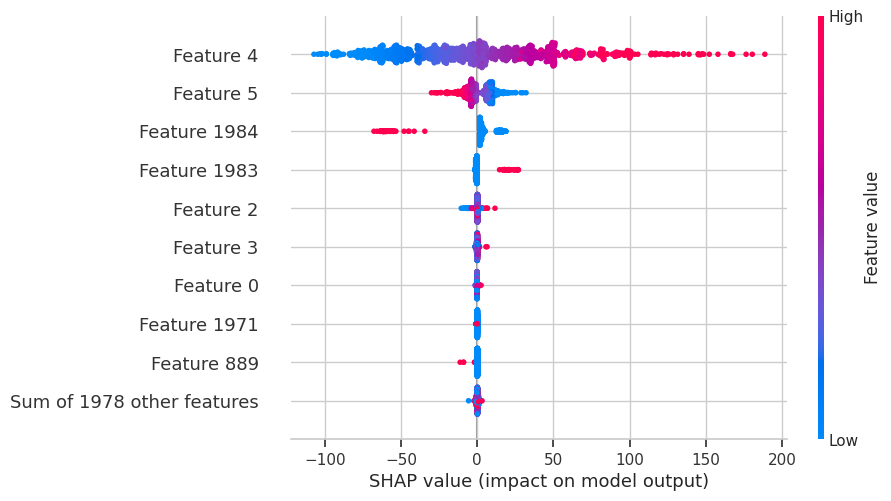

In [92]:
shap.plots.beeswarm(shap_values)

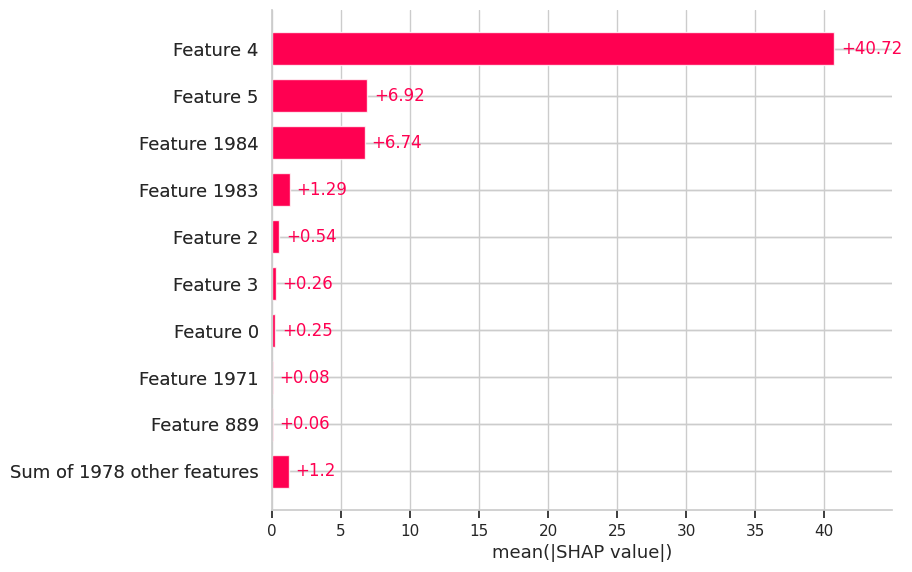

In [93]:
shap.plots.bar(shap_values)

In [94]:
# ============================================================
# Step 10 : Create SHAP Explainer
# ============================================================

rf_model = final_model.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP values calculated.")

SHAP values calculated.


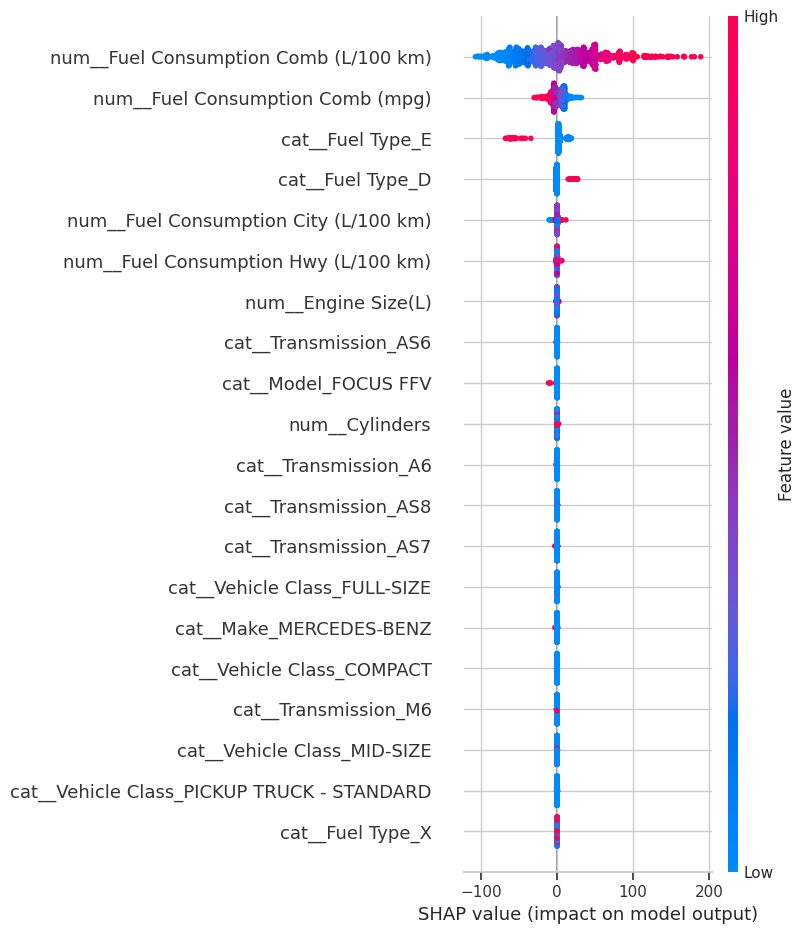

In [95]:
# ============================================================
# Step 10 : SHAP Summary Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

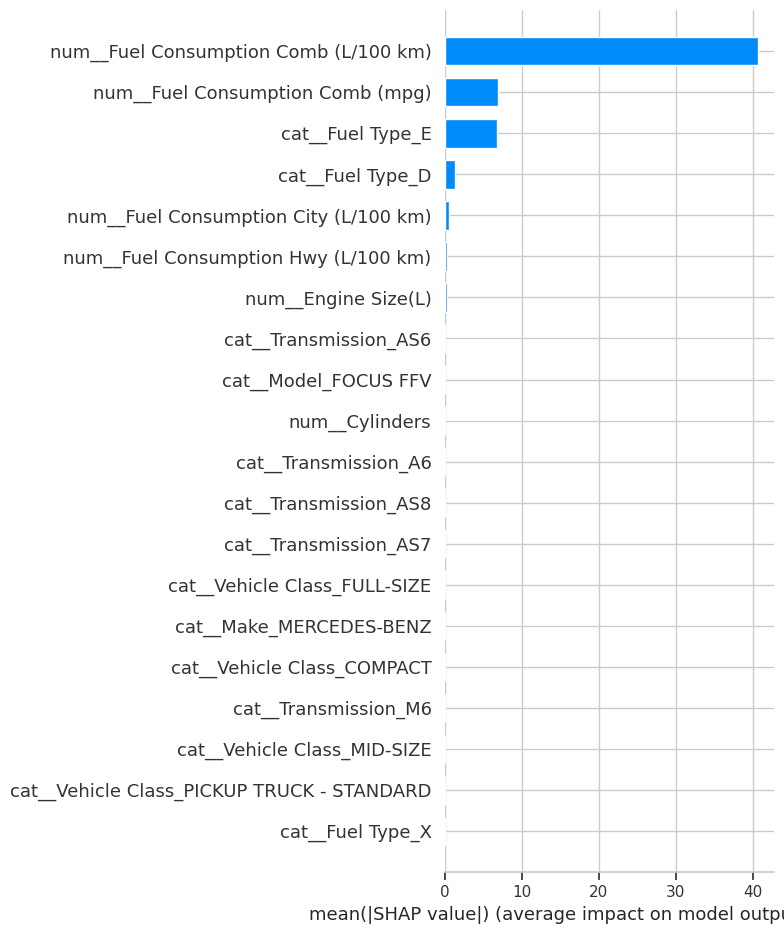

In [96]:
# ============================================================
# Step 10 : Global Feature Importance
# ============================================================

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

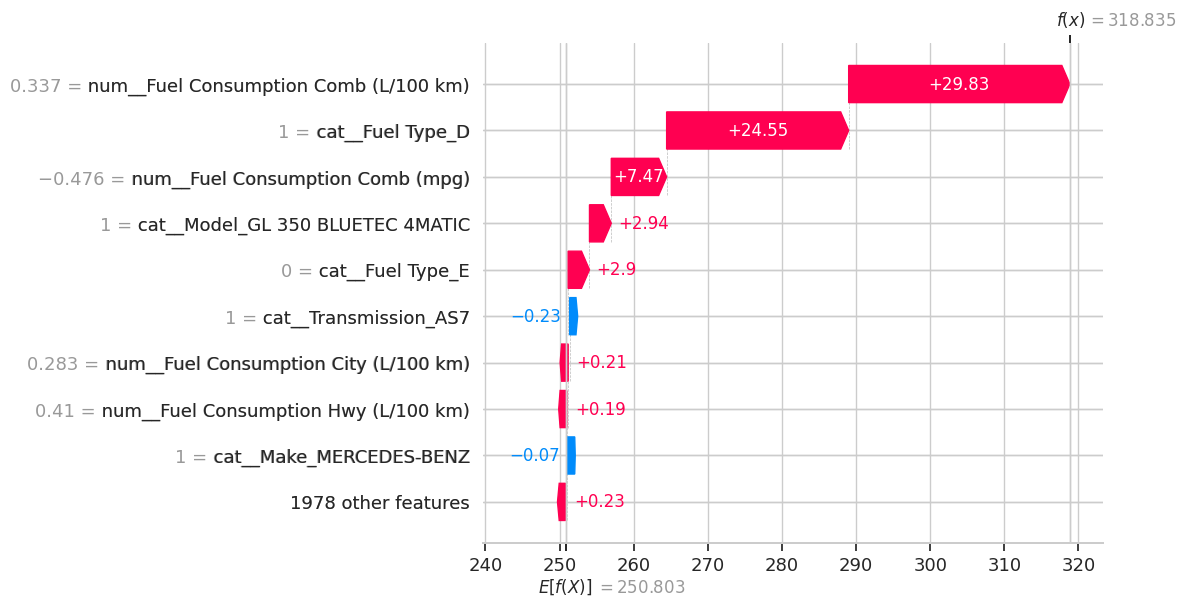

In [97]:
# ============================================================
# Step 10 : Explain One Prediction
# ============================================================

sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test_processed[sample_index],
        feature_names=feature_names
    )
)

# Step 11: Create a Prediction Function

In [98]:
# ============================================================
# Step 11 : Prediction Function
# ============================================================

def predict_vehicle_emission(
    make,
    model,
    vehicle_class,
    engine_size,
    cylinders,
    transmission,
    fuel_type,
    fuel_city,
    fuel_highway,
    fuel_comb,
    fuel_mpg
):
    """
    Predict CO₂ emissions for a vehicle.
    """

    input_df = pd.DataFrame({

        "Make": [make],
        "Model": [model],
        "Vehicle Class": [vehicle_class],
        "Engine Size(L)": [engine_size],
        "Cylinders": [cylinders],
        "Transmission": [transmission],
        "Fuel Type": [fuel_type],
        "Fuel Consumption City (L/100 km)": [fuel_city],
        "Fuel Consumption Hwy (L/100 km)": [fuel_highway],
        "Fuel Consumption Comb (L/100 km)": [fuel_comb],
        "Fuel Consumption Comb (mpg)": [fuel_mpg]

    })

    prediction = final_model.predict(input_df)

    return round(prediction[0], 2)

In [99]:
# test prediction
prediction = predict_vehicle_emission(

    make="FORD",
    model="F150 FFV 4X4",

    vehicle_class="PICKUP TRUCK - STANDARD",

    engine_size=5.0,

    cylinders=8,

    transmission="A6",

    fuel_type="X",

    fuel_city=18.2,

    fuel_highway=13.0,

    fuel_comb=15.9,

    fuel_mpg=18

)

print(f"Predicted CO₂ Emission : {prediction} g/km")

Predicted CO₂ Emission : 368.46 g/km


# Step 12: Save Project Artifacts

In [100]:
import os

os.makedirs("artifacts", exist_ok=True)

In [101]:
import joblib

joblib.dump(
    final_model,
    "artifacts/vehicle_co2_prediction_model.pkl"
)

['artifacts/vehicle_co2_prediction_model.pkl']

In [102]:
importance_df.to_csv(
    "artifacts/feature_importance.csv",
    index=False
)

In [103]:
results_df.to_csv(
    "artifacts/model_comparison.csv",
    index=False
)

# Step 13: Generate Project Visualizations

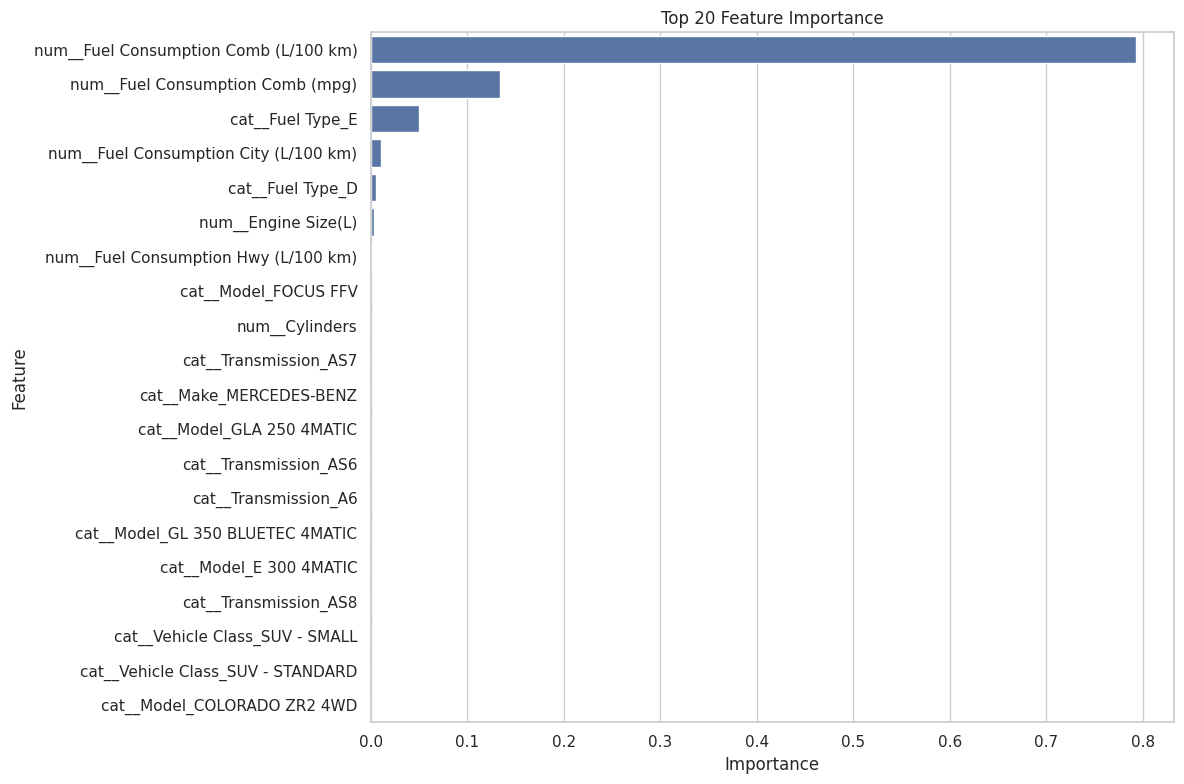

In [104]:
plt.figure(figsize=(12,8))

top_features = importance_df.head(20)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance")

plt.tight_layout()

plt.savefig(
    "artifacts/feature_importance.png",
    dpi=300
)

plt.show()

# Final Section: Interactive Plotly Dashboard

In [105]:
# ============================================================
# Step 11 : Install Plotly
# ============================================================

!pip install plotly -q

In [106]:
# ============================================================
# Step 11 : Import Libraries
# ============================================================

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [107]:
# ============================================================
# Recalculate Evaluation Metrics
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions
y_pred = final_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")

R² Score : 0.9957
MAE      : 2.17
RMSE     : 3.94


In [108]:
# ============================================================
# Step 11 : Dashboard Header
# ============================================================

print("=" * 80)
print(" VEHICLE CO₂ EMISSION PREDICTION DASHBOARD ")
print("=" * 80)

print(f"Best Model : Random Forest Regressor")
print(f"R² Score   : {r2:.4f}")
print(f"MAE        : {mae:.2f}")
print(f"RMSE       : {rmse:.2f}")

print("=" * 80)

 VEHICLE CO₂ EMISSION PREDICTION DASHBOARD 
Best Model : Random Forest Regressor
R² Score   : 0.9957
MAE        : 2.17
RMSE       : 3.94


In [109]:
# ============================================================
# Step 11 : KPI Dashboard
# ============================================================

fig = go.Figure()

fig.add_trace(
    go.Indicator(
        mode="number",
        value=r2,
        title={"text": "R² Score"},
        domain={"x":[0,0.30],"y":[0,1]}
    )
)

fig.add_trace(
    go.Indicator(
        mode="number",
        value=mae,
        title={"text":"MAE"},
        domain={"x":[0.35,0.65],"y":[0,1]}
    )
)

fig.add_trace(
    go.Indicator(
        mode="number",
        value=rmse,
        title={"text":"RMSE"},
        domain={"x":[0.70,1],"y":[0,1]}
    )
)

fig.update_layout(
    height=250,
    title="Model Performance Dashboard"
)

fig.show()

# Step 14 - Interactive Dashboard (4 Charts)

In [110]:
# ============================================================
# Step 12 : Interactive Plotly Dashboard
# ============================================================

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create 2x2 dashboard
fig = make_subplots(

    rows=2,
    cols=2,

    subplot_titles=(

        "Model Comparison (R² Score)",

        "Actual vs Predicted",

        "Residual Plot",

        "Top 10 Feature Importance"

    )

)

In [111]:
# ============================================================
# Model Comparison
# ============================================================

fig.add_trace(

    go.Bar(

        x=results_df["Model"],

        y=results_df["R² Score"],

        name="R² Score",

        marker_color="royalblue"

    ),

    row=1,
    col=1

)

In [112]:
# ============================================================
# Actual vs Predicted
# ============================================================

fig.add_trace(

    go.Scatter(

        x=y_test,

        y=y_pred,

        mode="markers",

        marker=dict(

            color="green",

            size=5

        ),

        name="Prediction"

    ),

    row=1,
    col=2

)

In [113]:
fig.add_trace(

    go.Scatter(

        x=[y_test.min(), y_test.max()],

        y=[y_test.min(), y_test.max()],

        mode="lines",

        line=dict(

            color="red",

            dash="dash"

        ),

        name="Ideal"

    ),

    row=1,
    col=2

)

In [114]:
# ============================================================
# Residual Plot
# ============================================================

residuals = y_test - y_pred

fig.add_trace(

    go.Scatter(

        x=y_pred,

        y=residuals,

        mode="markers",

        marker=dict(

            color="orange",

            size=5

        ),

        name="Residuals"

    ),

    row=2,
    col=1

)

In [115]:
fig.add_hline(

    y=0,

    line_dash="dash",

    line_color="red",

    row=2,

    col=1

)

In [116]:
# ============================================================
# Feature Importance
# ============================================================

top10 = importance_df.head(10)

fig.add_trace(

    go.Bar(

        x=top10["Importance"],

        y=top10["Feature"],

        orientation="h",

        marker_color="purple",

        name="Importance"

    ),

    row=2,
    col=2

)

In [117]:
# ============================================================
# Dashboard Layout
# ============================================================

fig.update_layout(

    title={

        "text": "Vehicle CO₂ Emission Prediction Dashboard",

        "x":0.5,

        "font":{

            "size":24

        }

    },

    template="plotly_white",

    height=900,

    width=1400,

    showlegend=False

)

fig.show()

# Step 15 - Executive Summary

In [118]:
# ============================================================
# Step 13 : Executive Summary
# ============================================================

print("=" * 80)
print("PROJECT EXECUTIVE SUMMARY")
print("=" * 80)

print(f"""
Business Problem
----------------
Predict vehicle CO₂ emissions based on vehicle specifications.

Dataset
-------
Canadian Vehicle CO₂ Emission Dataset

Records Used
------------
{len(df)}

Best Model
----------
Random Forest Regressor

Performance
-----------
R² Score : {r2:.4f}
MAE      : {mae:.2f}
RMSE     : {rmse:.2f}

Top Important Features
----------------------
1. Fuel Consumption (Combined)
2. Engine Size
3. Cylinders
4. Fuel Consumption (City)
5. Fuel Consumption (Highway)

Business Impact
---------------
• Estimate vehicle emissions before production.
• Support environmental compliance.
• Assist manufacturers in vehicle design optimization.
• Help consumers compare vehicle environmental impact.

Model Limitations
-----------------
• Based on historical vehicle data.
• Does not account for driving behaviour, road conditions,
  weather, or vehicle maintenance.
• Performance may decrease on unseen vehicle categories.

Future Improvements
-------------------
• Add hybrid and electric vehicle data.
• Incorporate real-world driving conditions.
• Retrain periodically with newer datasets.
• Deploy as a web application or REST API.
""")

print("=" * 80)

PROJECT EXECUTIVE SUMMARY

Business Problem
----------------
Predict vehicle CO₂ emissions based on vehicle specifications.

Dataset
-------
Canadian Vehicle CO₂ Emission Dataset

Records Used
------------
6282

Best Model
----------
Random Forest Regressor

Performance
-----------
R² Score : 0.9957
MAE      : 2.17
RMSE     : 3.94

Top Important Features
----------------------
1. Fuel Consumption (Combined)
2. Engine Size
3. Cylinders
4. Fuel Consumption (City)
5. Fuel Consumption (Highway)

Business Impact
---------------
• Estimate vehicle emissions before production.
• Support environmental compliance.
• Assist manufacturers in vehicle design optimization.
• Help consumers compare vehicle environmental impact.

Model Limitations
-----------------
• Based on historical vehicle data.
• Does not account for driving behaviour, road conditions,
  weather, or vehicle maintenance.
• Performance may decrease on unseen vehicle categories.

Future Improvements
-------------------
• Add hybrid

# Responsible AI and Ethical Considerations

## Fairness

The model was trained on publicly available vehicle specifications and
does not include personal or sensitive information.

## Bias

Predictions may be influenced by the distribution of vehicle types in
the training dataset. Vehicles that are underrepresented in the dataset
may produce less reliable predictions.

## Transparency

Feature importance analysis and SHAP explainability were used to
understand the factors contributing to the model's predictions.

## Privacy

The dataset contains only vehicle-related attributes and does not include
any personally identifiable information.

## Responsible Usage

This model should be used as a decision-support tool for estimating
vehicle CO₂ emissions. It should not replace official laboratory testing
or regulatory certification procedures.

# Improve Executive Summary

In [124]:
print("""
Business Recommendation
-----------------------

• Use the model as an early-stage decision support tool during vehicle design.

• Optimize engine size and fuel efficiency to reduce CO₂ emissions.

• Continuously retrain the model with new vehicle datasets to improve accuracy.

• Validate predictions with official emission testing before production.
""")


Business Recommendation
-----------------------

• Use the model as an early-stage decision support tool during vehicle design.

• Optimize engine size and fuel efficiency to reduce CO₂ emissions.

• Continuously retrain the model with new vehicle datasets to improve accuracy.

• Validate predictions with official emission testing before production.

